# Lab 12 Practice – Clustering (K-Means and K-Medoid)
**CS201L: Artificial Intelligence Laboratory | IIT Dharwad**

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import normalized_mutual_info_score, silhouette_score
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully.")


All libraries loaded successfully.


## 1. Data Preprocessing and Dimensionality Reduction

In [2]:
# (a) Load the Iris dataset
df = pd.read_csv('Iris.csv')
print("Shape:", df.shape)
df.head()


Shape: (150, 5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Features (columns 1-4) and true labels (column 5)
X = df.iloc[:, :4].values
true_labels_str = df.iloc[:, 4].values

# Encode string labels to integers for metric computation
label_map = {lbl: idx for idx, lbl in enumerate(np.unique(true_labels_str))}
true_labels = np.array([label_map[l] for l in true_labels_str])
print("Label mapping:", label_map)


Label mapping: {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}


In [4]:
# (b) Normalize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA → 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance retained: {:.2f}%".format(pca.explained_variance_ratio_.sum() * 100))


Explained variance ratio: [0.72770452 0.23030523]
Total variance retained: 95.80%


Saved iris_dataset_2D.csv


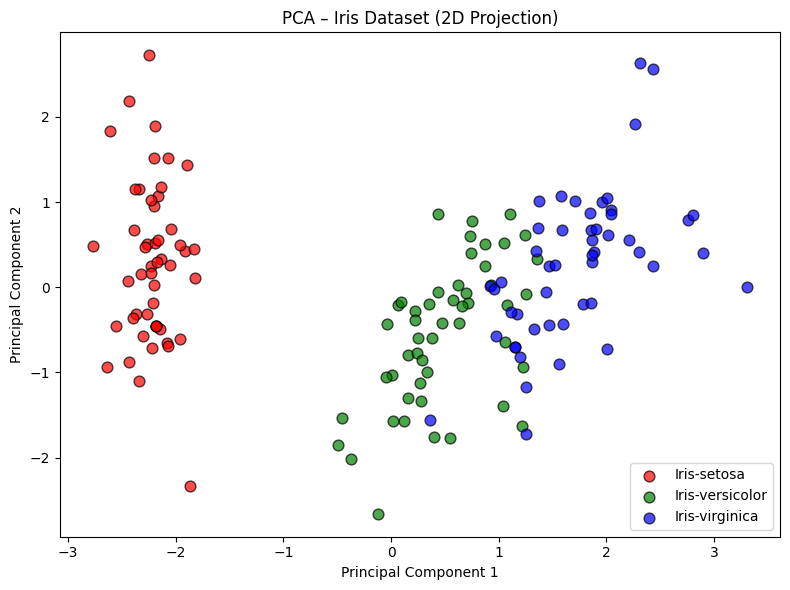

In [5]:
# (c) Save 2D dataset and visualize
df_2d = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_2d['Species'] = true_labels_str
df_2d.to_csv('iris_dataset_2D.csv', index=False)
print("Saved iris_dataset_2D.csv")

colors = {'Iris-setosa': 'red', 'Iris-versicolor': 'green', 'Iris-virginica': 'blue'}
plt.figure(figsize=(8, 6))
for species, color in colors.items():
    mask = true_labels_str == species
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=species, alpha=0.7, edgecolors='k', s=60)
plt.title('PCA – Iris Dataset (2D Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.savefig('pca_scatter.png', dpi=120)
plt.show()


## 2. K-Means Clustering

In [6]:
# (a) Load 2D dataset
df_2d = pd.read_csv('iris_dataset_2D.csv')
X_2d = df_2d[['PC1', 'PC2']].values


In [7]:
# (b) Apply K-Means (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_2d)
km_labels = kmeans.labels_
print("Cluster distribution:", Counter(km_labels))


Cluster distribution: Counter({0: 53, 1: 50, 2: 47})


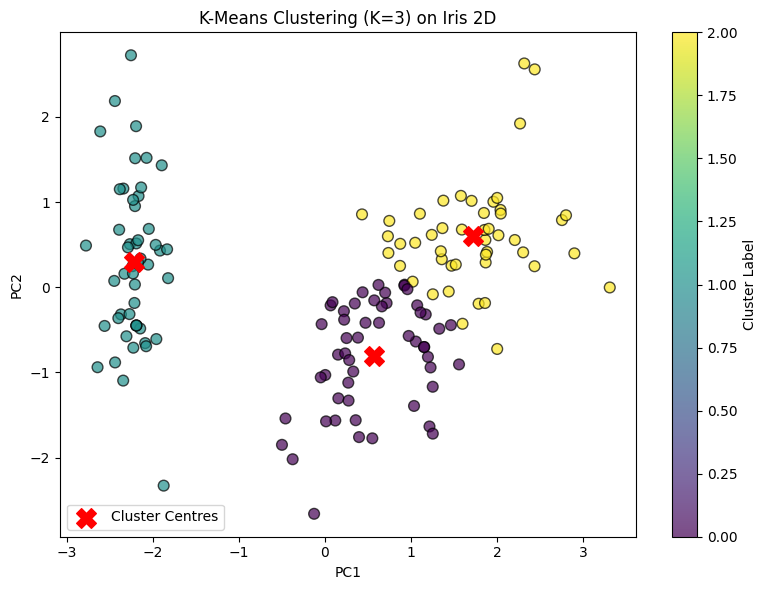

In [8]:
# (c) Scatter plot with cluster centres
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=km_labels, cmap='viridis', alpha=0.7, edgecolors='k', s=60)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, zorder=5, label='Cluster Centres')
plt.colorbar(scatter, label='Cluster Label')
plt.title('K-Means Clustering (K=3) on Iris 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.savefig('kmeans_scatter.png', dpi=120)
plt.show()


In [9]:
# (d) Purity Score
def purity_score(true_labels, cluster_labels):
    total = len(true_labels)
    purity = 0
    for cluster_id in np.unique(cluster_labels):
        mask = cluster_labels == cluster_id
        true_in_cluster = true_labels[mask]
        most_common_count = Counter(true_in_cluster).most_common(1)[0][1]
        purity += most_common_count
    return purity / total

km_purity = purity_score(true_labels, km_labels)
print(f"K-Means Purity Score: {km_purity:.4f}")


K-Means Purity Score: 0.8333


In [10]:
# (e) NMI Score
km_nmi = normalized_mutual_info_score(true_labels, km_labels)
print(f"K-Means NMI Score: {km_nmi:.4f}")


K-Means NMI Score: 0.6595


In [11]:
# (f) Silhouette Score
km_sil = silhouette_score(X_2d, km_labels)
print(f"K-Means Silhouette Score: {km_sil:.4f}")


K-Means Silhouette Score: 0.5082


  K=2: inertia = 198.7068
  K=4: inertia = 89.6199
  K=6: inertia = 57.2736
  K=10: inertia = 28.1260


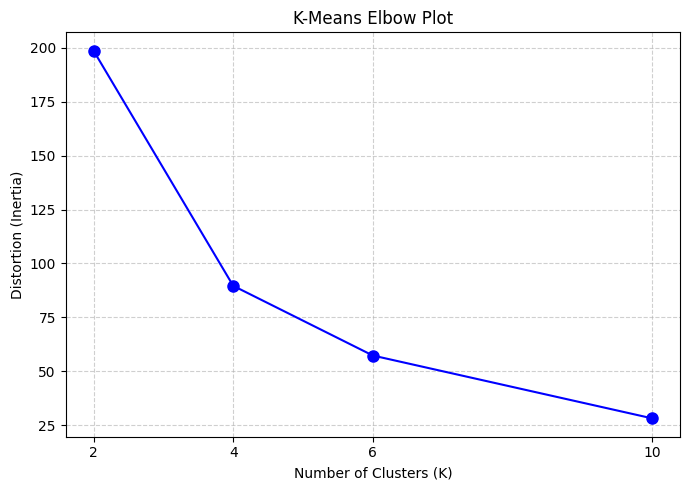


Heuristic optimum K (elbow): 4  — sharpest bend in the curve.


In [12]:
# (g) Distortion (inertia) for K = 2, 4, 6, 10  +  Elbow plot
K_values = [2, 4, 6, 10]
km_inertias = []
for k in K_values:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_k.fit(X_2d)
    km_inertias.append(km_k.inertia_)
    print(f"  K={k}: inertia = {km_k.inertia_:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(K_values, km_inertias, 'bo-', markersize=8)
plt.title('K-Means Elbow Plot')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Distortion (Inertia)')
plt.xticks(K_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=120)
plt.show()
print("\nHeuristic optimum K (elbow): 4  — sharpest bend in the curve.")


## 3. K-Medoid Clustering

In [13]:
# (a) Load 2D dataset (already in memory as X_2d)
# (b) Apply K-Medoids (K=3)
kmedoids = KMedoids(n_clusters=3, random_state=42)
kmedoids.fit(X_2d)
kmed_labels = kmedoids.labels_
print("Cluster distribution:", Counter(kmed_labels))


Cluster distribution: Counter({2: 58, 0: 49, 1: 43})


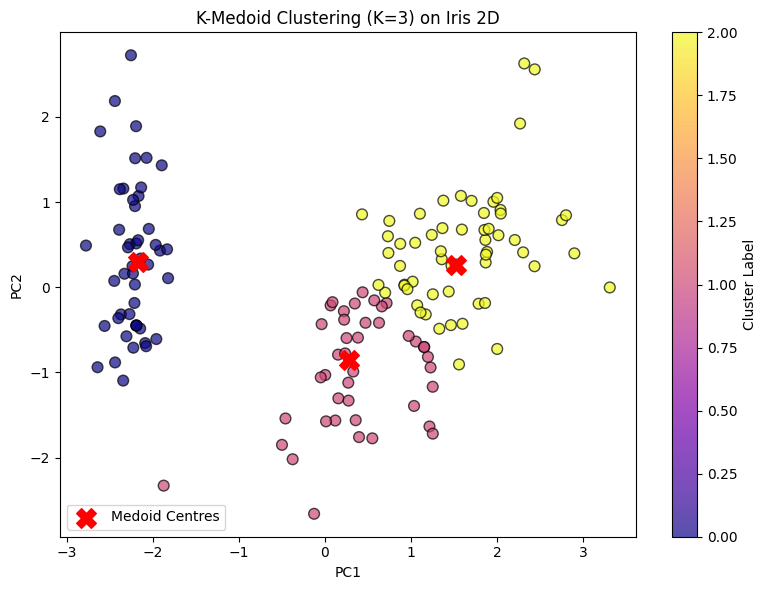

In [14]:
# (c) Scatter plot with medoid centres
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=kmed_labels, cmap='plasma', alpha=0.7, edgecolors='k', s=60)
medoid_centers = kmedoids.cluster_centers_
plt.scatter(medoid_centers[:, 0], medoid_centers[:, 1], c='red', marker='X', s=200, zorder=5, label='Medoid Centres')
plt.colorbar(scatter, label='Cluster Label')
plt.title('K-Medoid Clustering (K=3) on Iris 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.savefig('kmedoid_scatter.png', dpi=120)
plt.show()


In [15]:
# (d) Purity Score
kmed_purity = purity_score(true_labels, kmed_labels)
print(f"K-Medoid Purity Score: {kmed_purity:.4f}")


K-Medoid Purity Score: 0.8467


In [16]:
# (e) NMI Score
kmed_nmi = normalized_mutual_info_score(true_labels, kmed_labels)
print(f"K-Medoid NMI Score: {kmed_nmi:.4f}")


K-Medoid NMI Score: 0.6574


In [17]:
# (f) Silhouette Score
kmed_sil = silhouette_score(X_2d, kmed_labels)
print(f"K-Medoid Silhouette Score: {kmed_sil:.4f}")


K-Medoid Silhouette Score: 0.5008


  K=2: inertia = 145.6042
  K=4: inertia = 97.3661
  K=6: inertia = 84.1959
  K=10: inertia = 65.8988


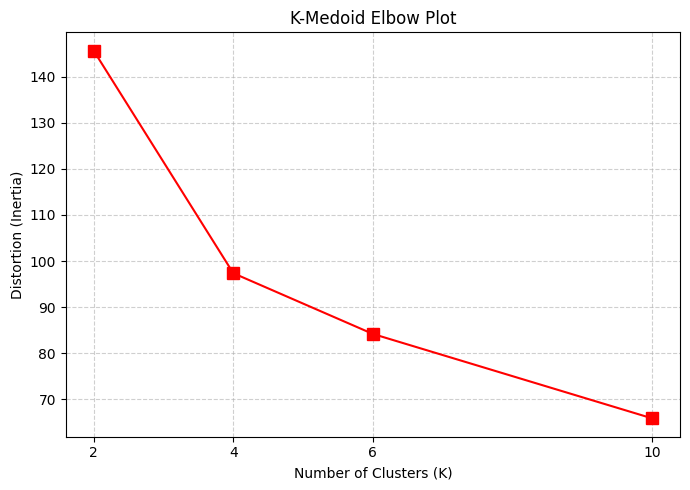


Heuristic optimum K (elbow): 4  — sharpest bend in the curve.


In [18]:
# (g) Distortion for K = 2, 4, 6, 10  +  Elbow plot
kmed_inertias = []
for k in K_values:
    kmed_k = KMedoids(n_clusters=k, random_state=42)
    kmed_k.fit(X_2d)
    kmed_inertias.append(kmed_k.inertia_)
    print(f"  K={k}: inertia = {kmed_k.inertia_:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(K_values, kmed_inertias, 'rs-', markersize=8)
plt.title('K-Medoid Elbow Plot')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Distortion (Inertia)')
plt.xticks(K_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('kmedoid_elbow.png', dpi=120)
plt.show()
print("\nHeuristic optimum K (elbow): 4  — sharpest bend in the curve.")


## Summary Comparison

In [19]:
summary = pd.DataFrame({
    'Metric': ['Purity', 'NMI', 'Silhouette'],
    'K-Means': [km_purity, km_nmi, km_sil],
    'K-Medoid': [kmed_purity, kmed_nmi, kmed_sil]
})
print(summary.to_string(index=False))


    Metric  K-Means  K-Medoid
    Purity 0.833333  0.846667
       NMI 0.659487  0.657423
Silhouette 0.508155  0.500796
